# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '/home/sara/lcpB/Computational-Physics-2026/Astrophysical-Objects-Recognition/stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

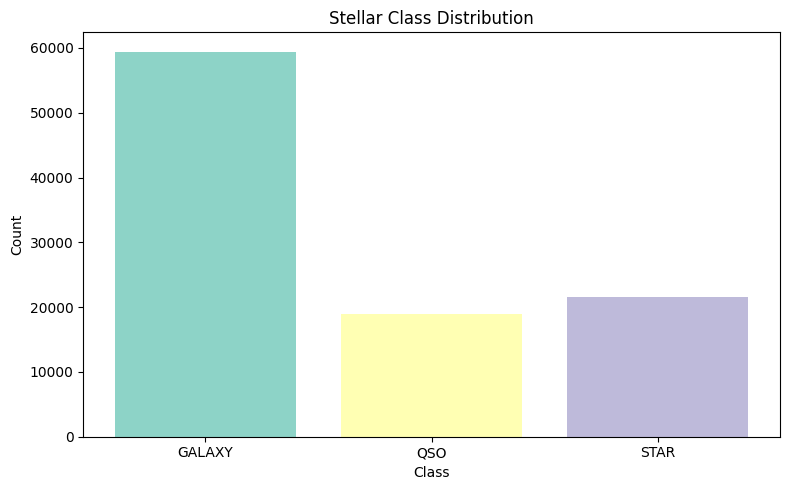

In [9]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [10]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 9,400 rows  (90,600 remain)
X_train shape: (106419, 10)
X_val shape: (18120, 10)
X_test shape: (18120, 10)


In [11]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [12]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=93.23%  P=0.93  R=0.93  F1=0.93
  [Validation] Acc=90.97%  P=0.84  R=0.93  F1=0.87
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=94.99%  P=0.90  R=0.94  F1=0.92
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=97.43%  P=0.95  R=0.96  F1=0.96
CatBoost trained.
  [Training] Acc=98.26%  P=0.98  R=0.98  F1=0.98
  [Validation] Acc=97.07%  P=0.94  R=0.96  F1=0.95
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 106419, number of used features: 10
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM trained.


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=97.85%  P=0.98  R=0.98  F1=0.98
  [Validation] Acc=96.88%  P=0.94  R=0.96  F1=0.95


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
# Train Voting Classifier utilizing the trained models
voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 106419, number of used features: 10
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=98.72%  P=0.99  R=0.99  F1=0.99
  [Validation] Acc=97.16%  P=0.95  R=0.96  F1=0.95


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
# Train PyTorch Neural Network
input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

nn_model = sc.train_neural(
    train_loader=train_loader,
    val_loader=val_loader,
    input_size=input_size,
    num_classes=num_classes,
    num_epochs=10,
    lr=0.001
)


Epoch  1/10  loss=0.2539  val_acc=94.34%
Epoch  2/10  loss=0.1619  val_acc=94.57%
Epoch  3/10  loss=0.1460  val_acc=95.26%
Epoch  4/10  loss=0.1373  val_acc=94.85%
Epoch  5/10  loss=0.1324  val_acc=95.42%
Epoch  6/10  loss=0.1287  val_acc=95.38%
Epoch  7/10  loss=0.1262  val_acc=95.49%
Epoch  8/10  loss=0.1237  val_acc=95.29%
Epoch  9/10  loss=0.1222  val_acc=95.23%
Epoch 10/10  loss=0.1203  val_acc=95.94%


In [15]:
# Base inference on test set
import torch 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)



Voting Classifier:
  Accuracy  : 97.25%
  Precision: 0.9473
  Recall   : 0.9617
  F1       : 0.9543
  Confusion Matrix:
[[11500   278    46]
 [  173  1820     1]
 [    1     0  4301]]

Neural Network:
  Accuracy  : 96.34%
  Precision: 0.9328
  Recall   : 0.9579
  F1       : 0.9448
  Confusion Matrix:
[[11331   311   182]
 [  165  1827     2]
 [    3     1  4298]]


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


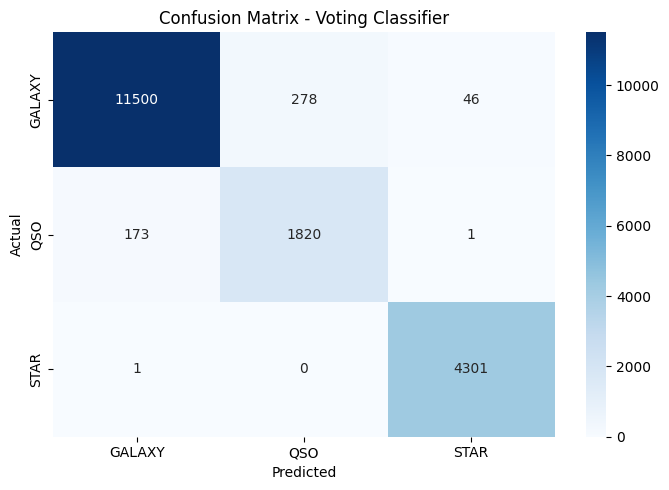

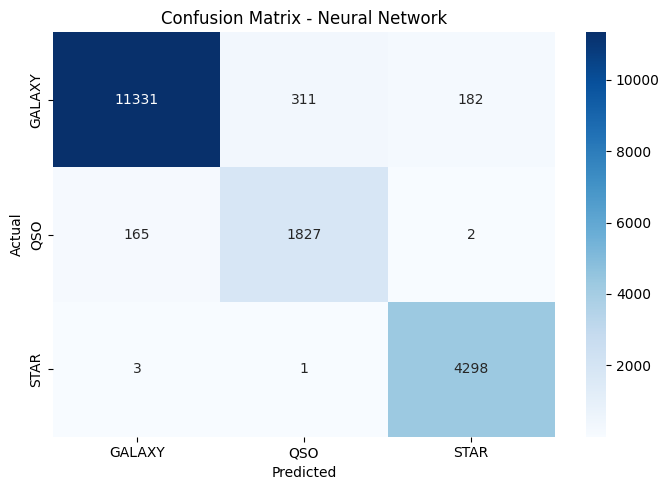

In [16]:
# Confusion Matrices
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

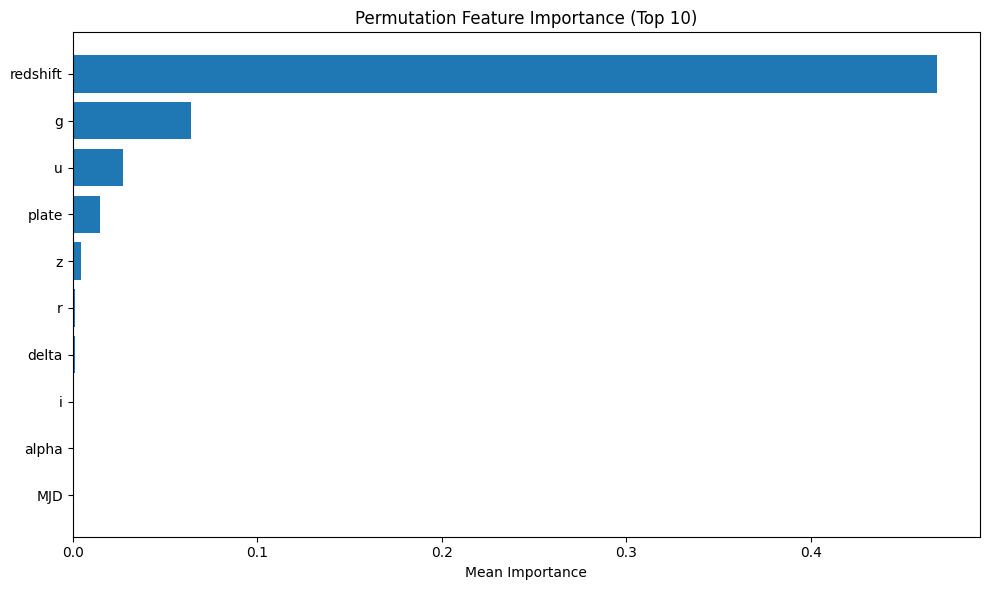

Feature Importance Scores:
redshift: 0.4683
g: 0.0642
u: 0.0273
plate: 0.0151
z: 0.0045
r: 0.0014
delta: 0.0012
i: 0.0010
alpha: 0.0006
MJD: 0.0006


In [17]:
# Feature Importance (using permutation importance on the Voting Classifier)
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")


In [ ]:
u=star['u']
g=star['g']
r=star['r']
i=star['i']
z=star['z']

0        23.87882
1        24.77759
2        25.26307
3        22.13682
4        19.43718
           ...   
99995    22.16759
99996    22.69118
99997    21.16916
99998    25.35039
99999    22.62171
Name: u, Length: 100000, dtype: float64

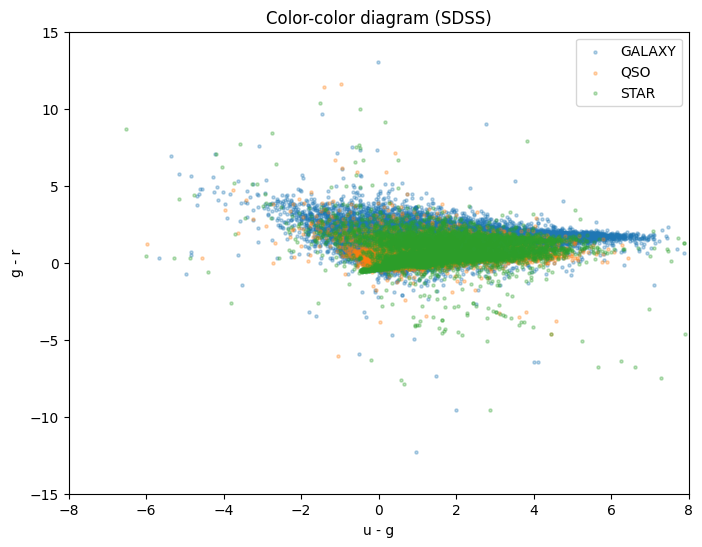

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

star = pd.read_csv(data_path)

# pulizia minima (fondamentale)
star = star.dropna(subset=['u','g','r','class'])

# indici di colore
star['u_g'] = star['u'] - star['g']
star['g_r'] = star['g'] - star['r']

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()

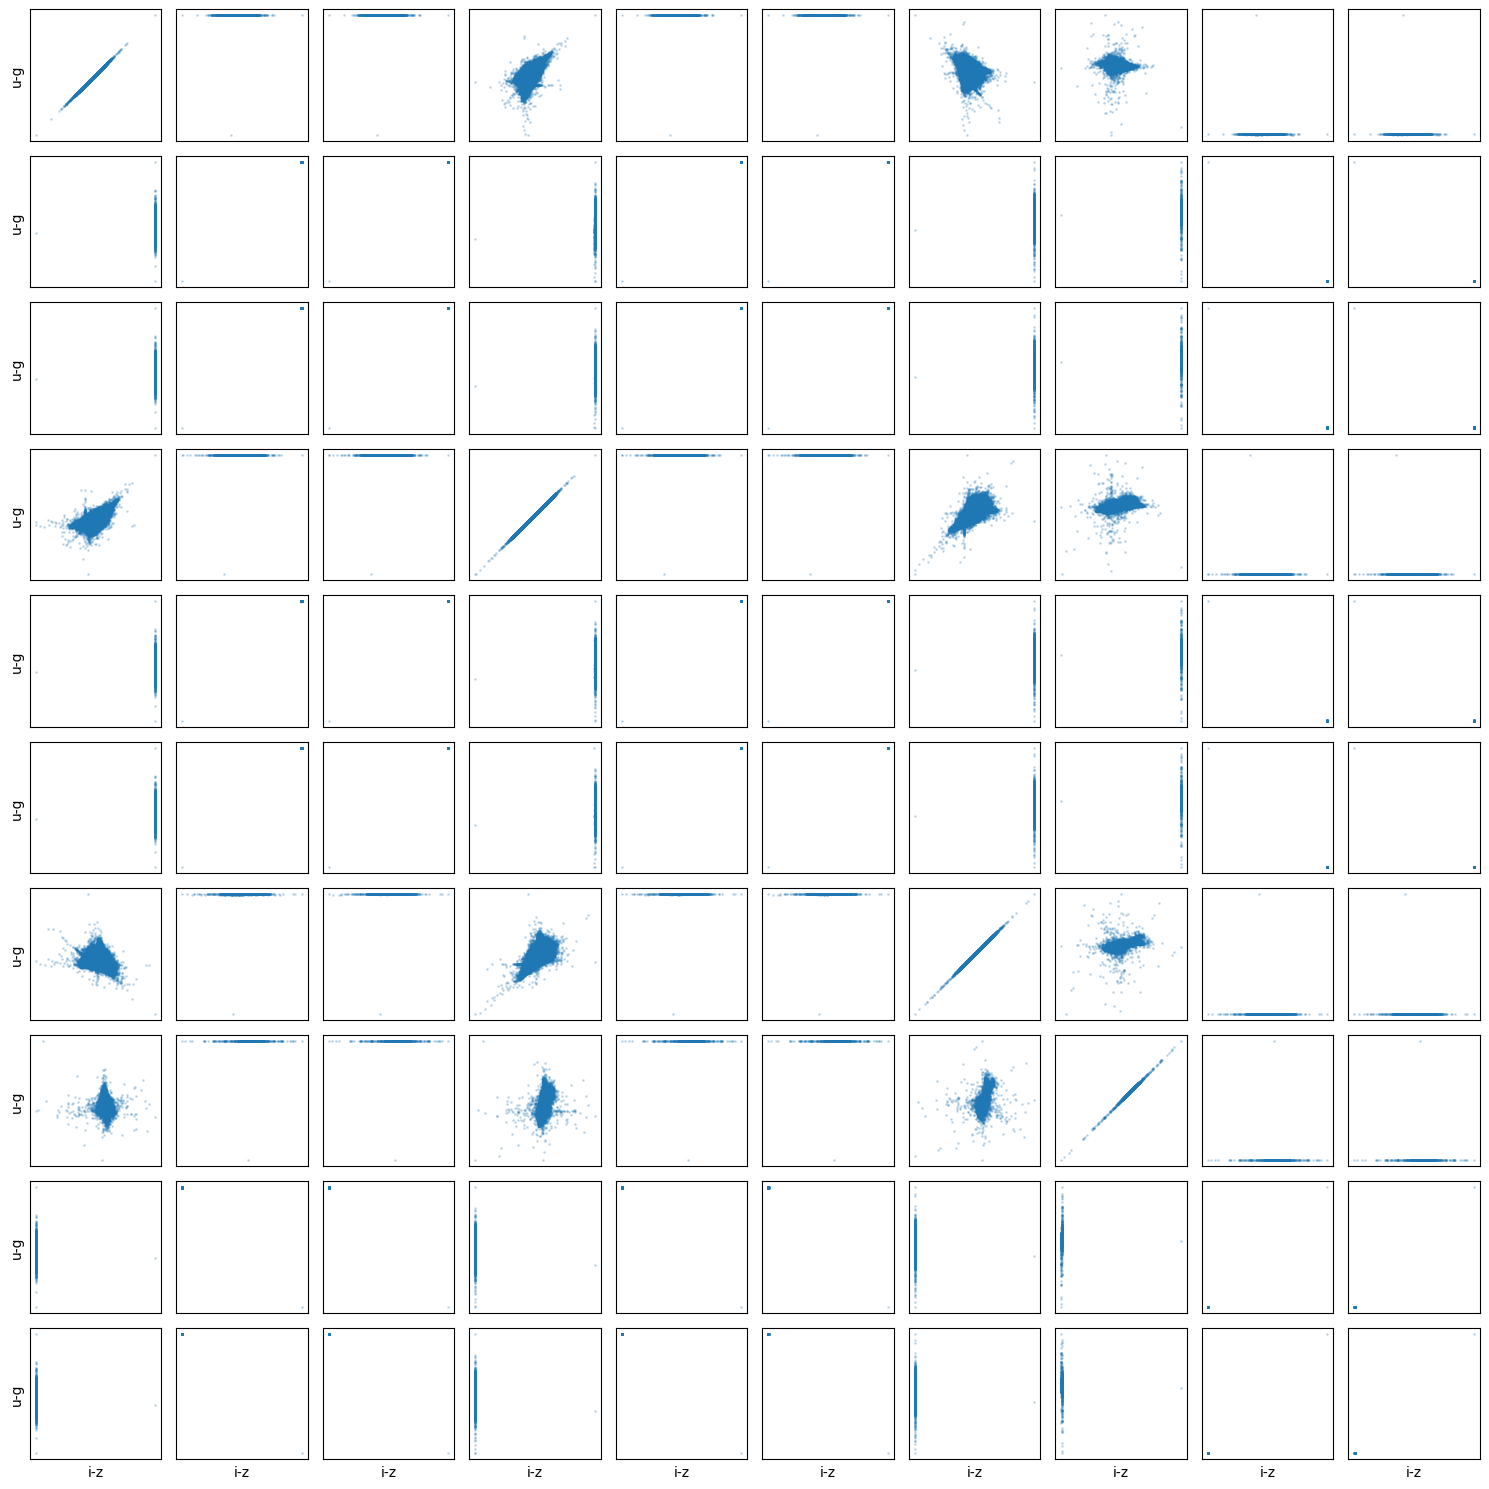

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

star = pd.read_csv(data_path)

# pulizia base
star = star.dropna()

bands = ['u', 'g', 'r', 'i', 'z']

pairs = list(combinations(bands, 2))

fig, axes = plt.subplots(len(pairs), len(pairs), figsize=(15,15))
axes = axes.reshape(len(pairs), len(pairs))

for i, (b1_x, b2_x) in enumerate(pairs):
    for j, (b1_y, b2_y) in enumerate(pairs):
        
        ax = axes[i, j]
        
        x = star[b1_x] - star[b2_x]
        y = star[b1_y] - star[b2_y]
        
        ax.scatter(x, y, s=1, alpha=0.2)
        
        # etichette solo sui bordi
        if i == len(pairs)-1:
            ax.set_xlabel(f'{b1_x}-{b2_x}')
        if j == 0:
            ax.set_ylabel(f'{b1_y}-{b2_y}')
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()